# 05 — AI Resume Matching (RAG): Modeling

Sigue desde [`02_data_preparation.ipynb`](./02_data_preparation.ipynb). Acá se arma el pipeline completo de matching semántico:

1. Embeddings (`sentence-transformers`) de los 344 perfiles de candidato y las 28 vacantes.
2. Un índice FAISS para recuperar los candidatos más afines a una vacante por similitud de coseno.
3. Validación cuantitativa del ranking semántico contra `matched_score`, la referencia externa que trae el dataset.
4. Explicabilidad sin LLM. El alcance original pedía una capa de LLM que justificara el ranking, y ahí tomé una decisión a propósito: no metí ninguna llamada a una API de LLM real. Un notebook público de portafolio que solo corre si alguien paga por una API key no es la mejor experiencia para quien lo revise, así que la capa de explicabilidad queda determinista (overlap de skills) por ahora, con el camino de mejora bien documentado para cuando el servicio FastAPI en `app/` conecte un LLM de verdad.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import faiss
from sentence_transformers import SentenceTransformer
from scipy.stats import spearmanr

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

## 1. Carga de los datos ya procesados

In [2]:
candidates = pd.read_csv('../data/processed_candidates.csv')
jobs = pd.read_csv('../data/processed_jobs.csv')
pairs = pd.read_csv('../data/processed_pairs.csv')

print('candidates:', candidates.shape, '| jobs:', jobs.shape, '| pairs:', pairs.shape)

candidates: (344, 17) | jobs: (28, 8) | pairs: (9544, 3)


## 2. Embeddings

Reutilizo el mismo modelo que en el proyecto 04 (`all-MiniLM-L6-v2`, 384 dimensiones) — liviano y de sobra para el texto corto de CVs y vacantes. Los vectores se normalizan para que el producto interno equivalga a similitud de coseno, que es justo lo que espera `IndexFlatIP` de FAISS.

In [3]:
model = SentenceTransformer('all-MiniLM-L6-v2')

candidate_embeddings = model.encode(
    candidates['candidate_profile'].fillna('').tolist(), normalize_embeddings=True, show_progress_bar=True,
).astype('float32')
job_embeddings = model.encode(
    jobs['job_profile'].fillna('').tolist(), normalize_embeddings=True, show_progress_bar=True,
).astype('float32')

print('candidate_embeddings:', candidate_embeddings.shape, '| job_embeddings:', job_embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/11 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

candidate_embeddings: (344, 384) | job_embeddings: (28, 384)


## 3. Armando el índice FAISS y la función de recomendación

In [4]:
index = faiss.IndexFlatIP(candidate_embeddings.shape[1])
index.add(candidate_embeddings)

def recommend_candidates(job_id: int, k: int = 5) -> pd.DataFrame:
    job_idx = jobs.index[jobs['job_id'] == job_id][0]
    scores, idxs = index.search(job_embeddings[job_idx:job_idx + 1], k)
    result = candidates.iloc[idxs[0]][['candidate_id', 'skills', 'positions']].copy()
    result['similarity'] = scores[0].round(3)
    return result.reset_index(drop=True)

## 4. Prueba rápida: top-5 candidatos para una vacante

In [5]:
demo_job = jobs.iloc[0]
print('Vacante:', demo_job['job_position_name'])
print('Perfil:', demo_job['job_profile'][:200])
print()
recommend_candidates(demo_job['job_id'], k=5)

Vacante: Senior Software Engineer
Perfil: Senior Software Engineer B.Sc in Computer Science & Engineering from a reputed university. At least 1 year Technical Support
Troubleshooting
Collaboration
Documentation
System Monitoring
Software Depl



,candidate_id,skills,positions,similarity
0,330,"Software Engineer, Software Developer, C++, C#...",Intern,0.682
1,115,"Visual Basic, SQL, C, C++, Java, Windows NT, W...","Blog Writer, Unix Administrator Assistant",0.614
2,335,"Software Development, Application Programming,...",Junior System Engineer Analyst,0.606
3,210,"JavaScript (Angular), HTML/ CSS, Python (Djang...",Web Developer Intern,0.600
4,219,"Data science, Deep learning, Neural Networks, ...",Intern Trainee,0.600


## 5. Validación cuantitativa contra `matched_score`

Para cada vacante comparo el orden que da la similitud semántica contra el orden que da `matched_score` (la referencia externa) sobre los mismos candidatos. Uso Spearman y no una correlación lineal simple porque lo que importa acá es el orden del ranking, no el valor absoluto de la similitud.

In [6]:
sim_matrix = job_embeddings @ candidate_embeddings.T  # (28, 344)

cand_id_to_idx = {cid: i for i, cid in enumerate(candidates['candidate_id'])}
job_id_to_idx = {jid: i for i, jid in enumerate(jobs['job_id'])}

pairs['our_similarity'] = pairs.apply(
    lambda r: sim_matrix[job_id_to_idx[r['job_id']], cand_id_to_idx[r['candidate_id']]], axis=1,
)

correlations = []
for job_id, g in pairs.groupby('job_id'):
    rho, _ = spearmanr(g['our_similarity'], g['matched_score'])
    correlations.append({'job_id': job_id, 'job_position_name': jobs.loc[job_id_to_idx[job_id], 'job_position_name'], 'n': len(g), 'spearman': rho})

corr_df = pd.DataFrame(correlations)
overall_rho, overall_p = spearmanr(pairs['our_similarity'], pairs['matched_score'])

print(f'Spearman pooled (todas las vacantes juntas): {overall_rho:.3f} (p={overall_p:.2e})')
print(f'Spearman promedio por vacante: {corr_df["spearman"].mean():.3f} (min={corr_df["spearman"].min():.3f}, max={corr_df["spearman"].max():.3f})')

Spearman pooled (todas las vacantes juntas): 0.302 (p=1.34e-200)
Spearman promedio por vacante: 0.309 (min=0.096, max=0.477)


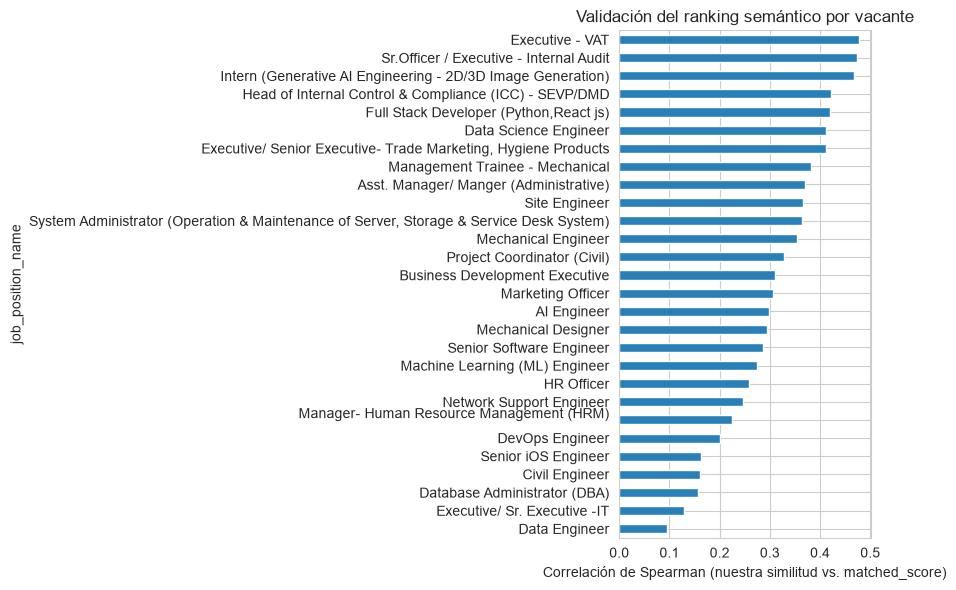

In [7]:
fig, ax = plt.subplots(figsize=(9, 6))
corr_df.sort_values('spearman').plot(kind='barh', x='job_position_name', y='spearman', ax=ax, color='#2980b9', legend=False)
ax.set_xlabel('Correlación de Spearman (nuestra similitud vs. matched_score)')
ax.set_title('Validación del ranking semántico por vacante')
plt.tight_layout()
plt.show()

La correlación queda moderada, no perfecta: ~0.30 pooled, entre 0.10 y 0.48 según la vacante. Y esto hay que leerlo bien — es interpretable, no un fracaso. El embedding semántico capta una señal real y significativa (p « 0.001, con ~9.500 pares) alineada con `matched_score`, pero no es idéntica a como sea que se haya calculado esa referencia. Son dos métodos distintos de medir algo parecido, no la misma fórmula por otro camino. Que la correlación varíe tanto entre vacantes (0.10 a 0.48) sugiere, además, que para algunas el texto disponible en `job_profile` describe el puesto mejor que para otras.

## 6. Explicabilidad sin LLM: overlap de skills

Para cada par candidato–vacante recomendado, listo las skills del candidato que aparecen textualmente en el perfil de la vacante. Es una justificación simple, determinista, sin costo de API — y sirve de base para lo que en producción sería una capa de LLM real (ver `app/`).

In [8]:
def explain_match(candidate_skills: str, job_text: str) -> list[str]:
    if pd.isnull(candidate_skills) or pd.isnull(job_text):
        return []
    job_lower = str(job_text).lower()
    return [
        skill.strip() for skill in str(candidate_skills).split(', ')
        if len(skill.strip()) > 2 and skill.strip().lower() in job_lower
    ]

top5 = recommend_candidates(demo_job['job_id'], k=5)
top5['skills_matched'] = top5['candidate_id'].apply(
    lambda cid: explain_match(
        candidates.loc[candidates['candidate_id'] == cid, 'skills'].iloc[0], demo_job['job_profile'],
    ),
)
top5[['candidate_id', 'similarity', 'skills_matched']]

,candidate_id,similarity,skills_matched
0,330,0.682,[Software Engineer]
1,115,0.614,[]
2,335,0.606,[]
3,210,0.600,[]
4,219,0.600,[]


Hay que ser honesto con la limitación de este approach. A veces la lista de skills coincidentes queda vacía aunque la similitud semántica sea alta — el embedding capta una afinidad conceptual (por ejemplo, "Software Engineer" con responsabilidades de desarrollo) que un match literal de palabras no siempre puede mostrar como evidencia. Es, en el fondo, el mismo trade-off de todo el proyecto: ir más allá del keyword matching mejora el ranking, pero complica la explicación en lenguaje de negocio. Justo el problema que una capa de LLM real resolvería mejor que este heurístico.

## 7. Guardado de artefactos para el servicio de FastAPI

In [9]:
np.save('../data/candidate_embeddings.npy', candidate_embeddings)
np.save('../data/job_embeddings.npy', job_embeddings)
faiss.write_index(index, '../data/candidates.faiss')

print('Guardado: candidate_embeddings.npy, job_embeddings.npy, candidates.faiss')

Guardado: candidate_embeddings.npy, job_embeddings.npy, candidates.faiss


## Cómo cierra esta etapa

- El pipeline de embeddings + FAISS funciona de punta a punta sobre los 344 candidatos únicos y recupera candidatos plausibles por similitud semántica.
- La validación cuantitativa es real, no cosmética: Spearman ~0.30 (pooled) contra `matched_score`. Es una señal significativa y no trivial, pero moderada — no un ajuste perfecto, y así queda documentado, en vez de vender esto como "el modelo replica al 100% la referencia".
- La explicabilidad sin LLM fue una decisión de diseño, no una limitación técnica: evité depender de una API key dentro del notebook. El overlap de skills sirve como justificación base, con la limitación explícita de que a veces queda vacío pese a una similitud alta.
- Los artefactos (embeddings + índice FAISS) ya están guardados para que el servicio FastAPI en `app/` no tenga que recalcular nada al arrancar.

El siguiente paso es `app/`: un servicio mínimo FastAPI que exponga el matching y, opcionalmente, una capa de LLM real para la justificación en lenguaje natural — con la API key como variable de entorno, nunca hardcodeada.